In [1]:
import matplotlib.pyplot as plt
from ESN import Reservoir
from narma import NARMA
from Qreservoir_fast import QReservoir
from tools import init_identity, tensor, partial_transpose, negativity, dagger, gen_input_states, init_two_mode_th, init_th, init_two_mode_sq, init_two_mode_sq_th, init_destroy, assess_dm_entanglement, entanglement, truncate_mantissa

import numpy as np
import qutip as qt
import scipy as sp
import copy
import time

#Pyörittelyt --------------------------------------------------------

In [2]:
classic = Reservoir(128)
classic.add_performance_task(NARMA(degree_=6))
classic.generate_inputs([1000,3000,5000])
classic.evolve_reservoir('task1', 'full')
classic.results['task1']

Added performance task 'NARMA(6, 0.3, 0.05, 0.375, 0)' as 'task1'


('NARMA(6, 0.3, 0.05, 0.375, 0)', np.float64(0.01258035121895656))

In [ ]:
for i in range(50):
    jeps = Reservoir(128, 0.9, 0.1)
    jeps.add_performance_task(NARMA(degree_=6))
    jeps.generate_inputs([1000,5000,3000])
    jeps.evolve_reservoir('task1', 'full')
    print(jeps.results['task1'])

In [ ]:
quantum = QReservoir(1, 4, 5, "alltoall")
quantum.init_reservoir("vacuum")
quantum.rk4_timesteps(4)

inputs = gen_input_states("sq_th", 200, 5, 12)

In [3]:
quantum.train_reservoir(inputs)
quantum.train_measured_observables_

tr_res: (1+0j)
tr_new: (0.9999999999889999+0j)
0
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000074665+0j)
1
tr_res: (1+0j)
tr_new: (1.0000000780550002+0j)
2
tr_res: (0.9999999403953552+0j)
tr_new: (0.9999999560020001+0j)
3
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999751713+0j)
4
tr_res: (0.9999996423721313+0j)
tr_new: (0.999999648697+0j)
5
tr_res: (0.9999996423721313+0j)
tr_new: (0.999999598035+0j)
6
tr_res: (0.9999996423721313+0j)
tr_new: (0.999999611267+0j)
7
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996272089999+0j)
8
tr_res: (0.9999995231628418+0j)
tr_new: (0.999999476273+0j)
9
tr_res: (0.999999463558197+0j)
tr_new: (0.99999946569+0j)
10
tr_res: (0.9999994039535522+0j)
tr_new: (0.9999994343220001+0j)


KeyboardInterrupt: 

In [ ]:
new_inputs = gen_input_states("sq_th", 200, 5, 12)
quantum.test_reservoir(new_inputs)

tr_res: (0.999996542930603+0j)
tr_new: (0.9999964463000001+0j)
0
tr_res: (0.9999964237213135+0j)
tr_new: (0.9999964125+0j)
1
tr_res: (0.9999964237213135+0j)
tr_new: (0.9999964146+0j)
2
tr_res: (0.9999964237213135+0j)
tr_new: (0.9999964433000001+0j)
3
tr_res: (0.999996542930603+0j)
tr_new: (0.9999964814+0j)
4
tr_res: (0.9999963045120239+0j)
tr_new: (0.9999963601000001+0j)
5
tr_res: (0.9999964237213135+0j)
tr_new: (0.9999964270999999+0j)
6
tr_res: (0.9999964237213135+0j)
tr_new: (0.9999963141000001+0j)
7
tr_res: (0.9999964833259583+0j)
tr_new: (0.9999964525+0j)
8
tr_res: (0.9999964237213135+0j)
tr_new: (0.9999964014999998+0j)
9
tr_res: (0.9999964237213135+0j)
tr_new: (0.9999964312+0j)
10
tr_res: (0.9999967813491821+0j)
tr_new: (0.9999966457999998+0j)
11
tr_res: (0.9999966621398926+0j)
tr_new: (0.9999965832+0j)
12
tr_res: (0.999996542930603+0j)
tr_new: (0.9999965050000001+0j)
13
tr_res: (0.9999963045120239+0j)
tr_new: (0.9999963412+0j)
14
tr_res: (0.9999963641166687+0j)
tr_new: (0.9999964

0.725

In [44]:
from ridge import RidgeRegression as Ridge1
from sklearn.linear_model import Ridge as Ridge2
from sklearn.preprocessing import StandardScaler

In [20]:
def assign_entanglement_from_probabilities(Y_pred):
    return np.array([[1,0] if x[0] >= x[1] else [0,1] for x in Y_pred])

def analyze_performance(Y_true, Y_pred):
    count_ = 0
    for x, y in zip(Y_true, Y_pred):
        if x[0] == y[0]:
            count_ += 1

    return count_ / len(Y_true)

In [ ]:
train_obs = quantum.train_measured_observables_
train_std1 = (train_obs - np.mean(train_obs, axis=0))/np.std(train_obs, axis=0)
train_Y_true = quantum.train_Y_true_

test_obs = quantum.test_measured_observables_
test_std1 = (test_obs - np.mean(test_obs, axis=0))/np.std(test_obs, axis=0)
test_Y_true = quantum.test_Y_true_

In [50]:
luvut = [0.000000001, 0.00000001, 0.0000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1]

tulos = []
for luku in luvut:
    malli1 = Ridge2(luku)
    malli2 = Ridge2(luku)
    malli1.fit(train_obs, train_Y_true[:,0])
    malli2.fit(train_obs, train_Y_true[:,1])
    Y_pred = np.array([malli1.predict(test_obs), malli2.predict(test_obs)])
    Y_pred = assign_entanglement_from_probabilities(Y_pred.T)
    result = analyze_performance(test_Y_true, Y_pred)
    tulos.append(result)
    
print(np.array(tulos))

tulos = []
for luku in luvut:
    malli1 = Ridge2(luku)
    malli2 = Ridge2(luku)
    malli1.fit(train_std1, train_Y_true[:,0])
    malli2.fit(train_std1, train_Y_true[:,1])
    Y_pred = np.array([malli1.predict(test_std1), malli2.predict(test_std1)])
    Y_pred = assign_entanglement_from_probabilities(Y_pred.T)
    result = analyze_performance(test_Y_true, Y_pred)
    tulos.append(result)
    
print(np.array(tulos))


[0.91  0.915 0.92  0.895 0.83  0.765 0.73  0.725 0.725 0.725]
[0.905 0.905 0.905 0.905 0.905 0.905 0.91  0.91  0.905 0.85 ]


In [2]:
amount_of_states = 10000
truncate = 5
reservoir_size = 4

theta_sq_th_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
s_sq_th_ = np.random.uniform(0.8,0.95,(amount_of_states,))
phi_sq_th_ = np.random.uniform(0.5-np.pi/10, 0.5+np.pi/10, (amount_of_states,))
abs_alpha_sq_th_ = np.array([x*np.sin(y) for x, y in zip(s_sq_th_,phi_sq_th_)])
alpha_sq_th_ = np.array([x*np.sin(y)*np.exp(1j*z) for x, y, z in zip(s_sq_th_,phi_sq_th_,theta_sq_th_)])
mean_n_sq_th_ = np.array([x*x*np.cos(y)*np.cos(y) for x, y in zip(s_sq_th_,phi_sq_th_)])

a1 = tensor([init_destroy(truncate), init_identity(truncate)])
a2 = tensor([init_identity(truncate), init_destroy(truncate)])

In [3]:
sq_matrix = [init_two_mode_sq(x, a1, a2) for x in alpha_sq_th_]
sq_matrix_trunc = [np.trunc(sq.real * 1e13) / 1e13 + 1j * (np.trunc(sq.imag * 1e13) / 1e13) for sq in sq_matrix]
inputs = [init_two_mode_sq_th(x, y, truncate, a1, a2) for x, y in zip(alpha_sq_th_,mean_n_sq_th_)]
inputs_trunc = [np.trunc(input.real * 1e13) / 1e13 + 1j * (np.trunc(input.imag * 1e13) / 1e13) for input in inputs]
pt_inputs = [partial_transpose(input, "first", 5, 5) for input in inputs]

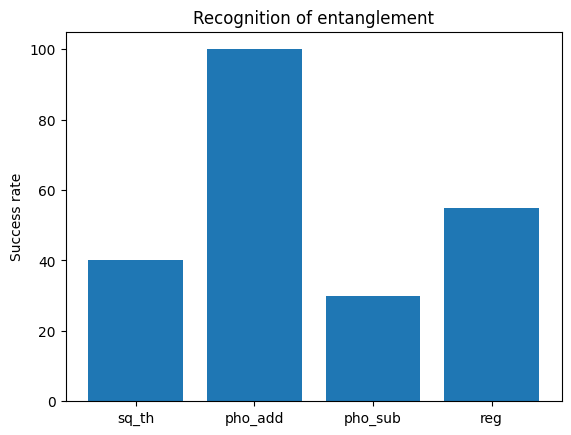

In [ ]:
#Plot the probability of correct classification
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()